## Install and Import important librairies

In [ ]:
#%pip install pandas
#%pip install yfinance
#%pip install lxml
#%pip install -U sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import numpy as np
import time
from datetime import datetime
from sklearn.metrics import silhouette_score
import yfinance as yf

## Get the list of stocks in the S&P 500

In [ ]:
# Read and print the stock tickers that make up S&P500
df_tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]

display(df_tickers.head())

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
ticker_list = df_tickers['Symbol'].str.strip().str.replace('.', '-', regex=False).tolist()
len(ticker_list)

503

## Get the news of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the news of all 500 stocks in the index.
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

### Get the news in a dictionary

In [ ]:
def fetch_news(tickers):
    """
    Fetches financial news for a list of tickers using yfinance.

    Args:
        tickers (list): List of stock symbols (tickers).

    Returns:
        dict: Dictionary with ticker as key and list of news articles as value.
    """
    news_dict = {}

    for idx, ticker in enumerate(tickers, start=1):
        try:
            stock = yf.Ticker(ticker)
            news = stock.news or []  # Ensure it's not None
            news_dict[ticker] = news
            print(f"{ticker}: {len(news)} news articles retrieved.")

        except Exception as e:
            print(f"Error fetching news for {ticker}: {e}")
            news_dict[ticker] = []

        # Show progress every 50 tickers or at the end
        if idx % 50 == 0 or idx == len(tickers):
            print(f"Processed {idx} out of {len(tickers)} tickers.")

        time.sleep(0.3)  # Pause to avoid API rate limiting

    return news_dict

# Use the function
news = fetch_news(ticker_list)

MMM: 10 news articles retrieved.
AOS: 10 news articles retrieved.
ABT: 10 news articles retrieved.
ABBV: 10 news articles retrieved.
ACN: 10 news articles retrieved.
ADBE: 10 news articles retrieved.
AMD: 10 news articles retrieved.
AES: 10 news articles retrieved.
AFL: 10 news articles retrieved.
A: 10 news articles retrieved.
APD: 10 news articles retrieved.
ABNB: 10 news articles retrieved.
AKAM: 10 news articles retrieved.
ALB: 10 news articles retrieved.
ARE: 10 news articles retrieved.
ALGN: 10 news articles retrieved.
ALLE: 10 news articles retrieved.
LNT: 10 news articles retrieved.
ALL: 10 news articles retrieved.
GOOGL: 10 news articles retrieved.
GOOG: 10 news articles retrieved.
MO: 10 news articles retrieved.
AMZN: 10 news articles retrieved.
AMCR: 10 news articles retrieved.
AEE: 10 news articles retrieved.
AEP: 10 news articles retrieved.
AXP: 10 news articles retrieved.
AIG: 10 news articles retrieved.
AMT: 10 news articles retrieved.
AWK: 10 news articles retrieved.
AM

### Structure the news into a pandas dataframe

Your final dataframe should have the following columns:
- TICKER
- TITLE (of the news)
- SUMMARY (of the news)
- PUBLICATION_DATE (of the news)
- URL (of the news)

Note: all of those fields are provided in the yfinance news component. Refer to the library documentation.

In [ ]:
news_rows = []

for ticker, articles in news.items():
    for article in articles:  # limite to 10 news
        content = article.get("content")
        if content is None:
            continue

        title = content.get("title")
        summary = content.get("summary")
        pub_date = content.get("pubDate")
        url = content.get("canonicalUrl", {}).get("url") if content.get("canonicalUrl") else None

        if title and url and pub_date:
            news_rows.append({
                "TICKER": ticker,
                "TITLE": title,
                "SUMMARY": summary,
                "PUBLICATION_DATE": pd.to_datetime(pub_date, errors='coerce'),
                "URL": url
            })

df_news = pd.DataFrame(news_rows)

df_news.head()

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24 09:03:00+00:00,https://finance.yahoo.com/news/3m-company-mmm-...
1,MMM,"Zacks Industry Outlook Highlights Honeywell, 3...","HON, MMM, CSL, and FSS are well-positioned to ...",2025-07-21 09:45:00+00:00,https://finance.yahoo.com/news/zacks-industry-...
2,MMM,"Stock Market News for Jul 21, 2025",U.S. stock markets closed mostly lower n Frida...,2025-07-21 08:22:00+00:00,https://finance.yahoo.com/news/stock-market-ne...
3,MMM,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,3M Co (MMM) reports a 12% increase in adjusted...,2025-07-19 07:05:47+00:00,https://finance.yahoo.com/news/3m-co-mmm-q2-20...
4,MMM,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,Industrial conglomerate 3M (NYSE:MMM) reported...,2025-07-19 05:30:58+00:00,https://finance.yahoo.com/news/mmm-q1-deep-div...


## Exploring text embeddings

- Use the open-source model: 'sentence-transformers/all-MiniLM-L6-v2' to create embeddings on the news title and summary
- Add a column to your news dataframe called EMBEDDED_TEXT using ONLY the TITLE of the news
- Add a column to your news dataframe called EMBEDDINGS, which contains the embedding of EMBEDDED_TEXT


In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

#load the pre-trained embedding model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

#create a new column EMBEDDED_TEXT with only the TITLE text
df_news['EMBEDDED_TEXT'] = df_news['TITLE']

#this returns a list of numpy arrays (embeddings)
embeddings = model.encode(df_news['EMBEDDED_TEXT'].tolist(), show_progress_bar=True)

#add the embeddings to the dataframe
df_news['EMBEDDINGS'] = embeddings.tolist()

#check the result
df_news[['TICKER','TITLE', 'EMBEDDED_TEXT', 'EMBEDDINGS']].head()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

,TICKER,TITLE,EMBEDDED_TEXT,EMBEDDINGS
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455428432673216, -0.10904759913682938, -..."
1,MMM,"Zacks Industry Outlook Highlights Honeywell, 3...","Zacks Industry Outlook Highlights Honeywell, 3...","[-0.021629272028803825, -0.07978320866823196, ..."
2,MMM,"Stock Market News for Jul 21, 2025","Stock Market News for Jul 21, 2025","[-0.037469591945409775, -0.04381371662020683, ..."
3,MMM,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,"[-0.08080154657363892, -0.029800796881318092, ..."
4,MMM,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,"[-0.019502662122249603, -0.07280391454696655, ..."


## Using K-means clustering on news embeddings
to simplify, keep only one news for each company (ticker), you should have 500 rows in your news dataframe

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

#Keep only one news article per TICKER (first one found)
df_one_news = df_news.drop_duplicates(subset=['TICKER'], keep='first').reset_index(drop=True)

#Confirm you now have 500 unique rows (tickers)
print(f"Number of unique tickers (rows): {len(df_one_news)}")  # Should print 500

#Convert EMBEDDINGS column to a NumPy array
embeddings_array = np.array(df_one_news['EMBEDDINGS'].tolist())

#Apply K-means clustering
num_clusters = 10  # You can change this depending on your use case
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_array)

#Add the cluster labels to your DataFrame
df_one_news['CLUSTER'] = cluster_labels

#Print the number of articles in each cluster
print(df_one_news['CLUSTER'].value_counts())

#Show 3 example titles per cluster
for i in sorted(df_one_news['CLUSTER'].unique()):
    sample_titles = df_one_news[df_one_news['CLUSTER'] == i]['TITLE'].head(3).tolist()
    print(f"\nCluster {i} sample titles:")
    print(sample_titles)

Number of unique tickers (rows): 502
CLUSTER
6    134
8     69
7     59
5     48
9     46
3     45
0     31
4     26
1     26
2     18
Name: count, dtype: int64

Cluster 0 sample titles:
['Align Technology, Inc. (ALGN): A Bull Case Theory', 'Arch Capital Group (ACGL) Expands Health Product Suite With New Supplement Offerings', 'Baxter recalls certain Novum pumps over issues tied to 79 injuries, 2 deaths']

Cluster 1 sample titles:
['Earnings Beat: A. O. Smith Corporation Just Beat Analyst Forecasts, And Analysts Have Been Updating Their Models', 'Earnings Beat: Ameriprise Financial, Inc. Just Beat Analyst Forecasts, And Analysts Have Been Updating Their Models', 'Oil Rig Count Drops by 7; Crude Prices Set for Back-to-Back Weekly Decline']

Cluster 2 sample titles:
['Federal Reserve meeting, July jobs report, and Big Tech earnings: What to watch this week', 'Federal Reserve meeting, July jobs report, and Big Tech earnings: What to watch this week', 'Federal Reserve meeting, July jobs re

### Identify the number of clusters using the silhouette score

- Using a for loop, do the clustering with different k values (number of clusters), test 1 to 6 clusters
- Compute the silhouette score for every k value
- Plot the silhouette score for different k values

#### Try different values of k and compute silhouette scores

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

# Convert embeddings column to numpy array
embeddings_array = np.array(df_one_news['EMBEDDINGS'].tolist())

silhouette_scores = []

# Test cluster numbers from 2 to 6 (1 cluster is not valid for silhouette)
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings_array)

    score = silhouette_score(embeddings_array, cluster_labels)
    silhouette_scores.append(score)

    print(f"Number of clusters: {k} -> Silhouette score: {score:.4f}")

Number of clusters: 2 -> Silhouette score: 0.0378
Number of clusters: 3 -> Silhouette score: 0.0470
Number of clusters: 4 -> Silhouette score: 0.0442
Number of clusters: 5 -> Silhouette score: 0.0248
Number of clusters: 6 -> Silhouette score: 0.0352


#### Plot silhouette scores

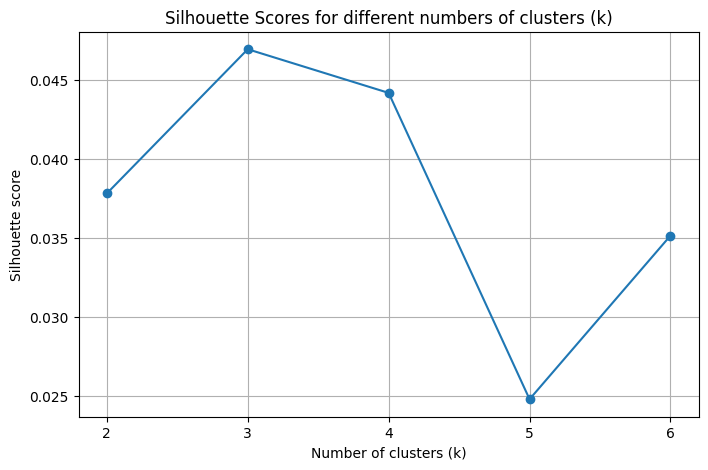

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS
# Plotting the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), silhouette_scores, marker='o')
plt.title('Silhouette Scores for different numbers of clusters (k)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(range(2, 7))
plt.grid(True)
plt.show()

#### Identify the Best k

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

# Assume silhouette_scores is the list of scores for k=2..6
k_values = range(2, 7)

best_score = max(silhouette_scores)
best_k = k_values[silhouette_scores.index(best_score)]

print(f"The best number of clusters is: {best_k} with a silhouette score of {best_score:.4f}")

The best number of clusters is: 3 with a silhouette score of 0.0470


#### Cluster the embeddings using 3 clusters (k=3)

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

# Convert embeddings column to numpy array
embeddings_array = np.array(df_one_news['EMBEDDINGS'].tolist())

# Define number of clusters
k = 3

# Create and fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_array)

# Add cluster labels to your dataframe
df_one_news['CLUSTER'] = cluster_labels

# Show cluster counts
print(df_one_news['CLUSTER'].value_counts())

# Optionally, display some sample titles per cluster
for cluster_num in range(k):
    print(f"\nCluster {cluster_num} sample titles:")
    sample_titles = df_one_news[df_one_news['CLUSTER'] == cluster_num]['TITLE'].head(3).tolist()
    for title in sample_titles:
        print(f"- {title}")

CLUSTER
1    208
2    161
0    133
Name: count, dtype: int64

Cluster 0 sample titles:
- 3M Company (MMM): “I Was Surprised” By The Organic Growth Rate, Says Jim Cramer
- A Data Deluge Brings a ‘Moment of Truth’ for Markets This Week
- Street Calls of the Week

Cluster 1 sample titles:
- The Smartest Dividend Stocks to Buy With $350 Right Now
- Accenture’s (ACN) Oversold Status May Offer a Smart Entry Point for Dividend Investors
- What Are the 3 Best Bargain Artificial Intelligence (AI) Stocks to Buy Right Now

Cluster 2 sample titles:
- Earnings Beat: A. O. Smith Corporation Just Beat Analyst Forecasts, And Analysts Have Been Updating Their Models
- Agilent Technologies' Q3 2025 Earnings: What to Expect
- Akamai Technologies Earnings Preview: What to Expect


### Visualize the 2 first PCA Components of your embeddings

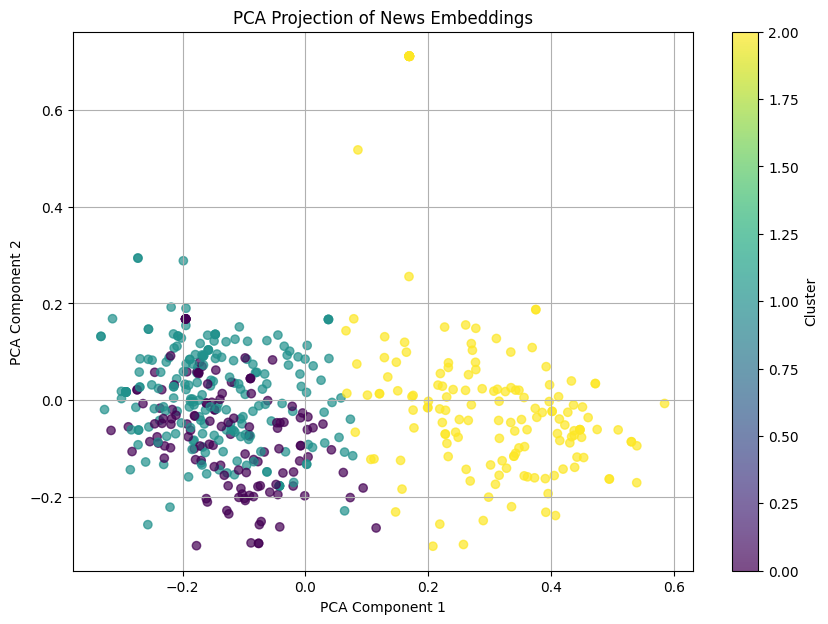

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

# Convert embeddings to numpy array
embeddings_array = np.array(df_one_news['EMBEDDINGS'].tolist())

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
components = pca.fit_transform(embeddings_array)

# Add PCA components to your DataFrame
df_one_news['PCA1'] = components[:, 0]
df_one_news['PCA2'] = components[:, 1]

# Plotting
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_one_news['PCA1'], df_one_news['PCA2'],
                      c=df_one_news['CLUSTER'], cmap='viridis', alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.title('PCA Projection of News Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

#### Analyze the content of each cluster
- Add the kmeans cluster label to your news dataframe
- Print the content of each cluster and analyze it

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

# Convert embeddings to numpy array if needed
embeddings_array = np.array(df_one_news['EMBEDDINGS'].tolist())

# Apply KMeans clustering with k=3 (you can adjust this value)
kmeans = KMeans(n_clusters=3, random_state=42)
df_one_news['CLUSTER'] = kmeans.fit_predict(embeddings_array)

In [ ]:
from collections import Counter
import re

print("\n=== Cluster Content Analysis ===\n")

for cluster_id in sorted(df_one_news['CLUSTER'].unique()):
    cluster_data = df_one_news[df_one_news['CLUSTER'] == cluster_id]
    print(f"Cluster {cluster_id}")
    print(f"Total articles: {len(cluster_data)}")

    # Show a few example titles
    print("\n Sample Titles:")
    for title in cluster_data['TITLE'].head(5):
        print(f" - {title}")

    # Analyze frequent words in the full text (if 'TEXT' column exists)
    if 'TEXT' in cluster_data.columns:
        combined_text = " ".join(cluster_data['TEXT'].dropna().tolist()).lower()
        words = re.findall(r'\b[a-z]{4,}\b', combined_text)
        top_words = Counter(words).most_common(10)
        keywords = [word for word, _ in top_words]
        print("\n Most Frequent Words:", ", ".join(keywords))

    print("\n" + "-" * 60 + "\n")


=== Cluster Content Analysis ===

Cluster 0
Total articles: 133

 Sample Titles:
 - 3M Company (MMM): “I Was Surprised” By The Organic Growth Rate, Says Jim Cramer
 - A Data Deluge Brings a ‘Moment of Truth’ for Markets This Week
 - Street Calls of the Week
 - Green Hydrogen Boom Fizzles as Projects Collapse Worldwide
 - Airbnb's Cash Cow Can Thrive Despite Its Challenges

------------------------------------------------------------

Cluster 1
Total articles: 208

 Sample Titles:
 - The Smartest Dividend Stocks to Buy With $350 Right Now
 - Accenture’s (ACN) Oversold Status May Offer a Smart Entry Point for Dividend Investors
 - What Are the 3 Best Bargain Artificial Intelligence (AI) Stocks to Buy Right Now
 - Investors Are Flocking to the Stock Market’s Discount Rack
 - 3 Reasons AFL is Risky and 1 Stock to Buy Instead

------------------------------------------------------------

Cluster 2
Total articles: 161

 Sample Titles:
 - Earnings Beat: A. O. Smith Corporation Just Beat Anal

In [ ]:
df_one_news.head()

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,EMBEDDINGS,CLUSTER,PCA1,PCA2
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24 09:03:00+00:00,https://finance.yahoo.com/news/3m-company-mmm-...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455428432673216, -0.10904759913682938, -...",0,-0.121831,-0.069905
1,AOS,Earnings Beat: A. O. Smith Corporation Just Be...,Investors in A. O. Smith Corporation ( NYSE:AO...,2025-07-27 12:40:47+00:00,https://finance.yahoo.com/news/earnings-beat-o...,Earnings Beat: A. O. Smith Corporation Just Be...,"[-0.042056772857904434, -0.042881302535533905,...",2,0.083626,0.075086
2,ABT,A Data Deluge Brings a ‘Moment of Truth’ for M...,(Bloomberg) -- Wall Street pros are staring do...,2025-07-27 19:00:00+00:00,https://finance.yahoo.com/news/data-deluge-bri...,A Data Deluge Brings a ‘Moment of Truth’ for M...,"[-0.06686529517173767, -0.031674452126026154, ...",0,-0.194935,0.168014
3,ABBV,The Smartest Dividend Stocks to Buy With $350 ...,"These stocks offer juicy dividends, solid grow...",2025-07-26 08:50:00+00:00,https://www.fool.com/investing/2025/07/26/the-...,The Smartest Dividend Stocks to Buy With $350 ...,"[-0.03801653906702995, -0.09102774411439896, -...",1,-0.214770,0.137182
4,ACN,Accenture’s (ACN) Oversold Status May Offer a ...,Accenture plc (NYSE:ACN) is included among the...,2025-07-26 03:44:43+00:00,https://finance.yahoo.com/news/accenture-acn-o...,Accenture’s (ACN) Oversold Status May Offer a ...,"[-0.07867276668548584, -0.07679503411054611, 0...",1,-0.103023,-0.048469


## Question Section

Take time to reflect on what you've implemented and observed. Answer the following questions in a separate markdown cell or notebook file:

---

### Technical Understanding

#### 1️⃣ How might the choice of embedding model (e.g., MiniLM vs. a larger transformer) affect your clustering results and interpretation?

Using MiniLM is fast and efficient, but it generates less detailed embeddings, which may lead to more general or mixed clusters, making each group harder to interpret.

In contrast, using a larger model like all-mpnet-base-v2 improves the semantic quality of the embeddings and produces more coherent and thematically distinct clusters.

---

#### 2️⃣ What would be the differences in embeddings if you used only the TITLE, only the SUMMARY, or the combination of both? How could you empirically test this?

- Using only the TITLE gives concise but limited context.
- Using only the SUMMARY adds depth and detail.
- Combining TITLE + SUMMARY usually produces richer embeddings and better clustering.

---

#### 3️⃣ In what situations would using a different dimensionality reduction method (e.g., t-SNE, UMAP) be preferable over PCA for visualization of embeddings?

PCA is great because it’s fast and simple—it looks for the biggest overall differences in your data, giving you a quick, general picture. But it’s a linear method, so it can miss the more subtle, curved relationships in complex data.

On the other hand, t-SNE and UMAP are designed to capture those local similarities really well. They help you see clusters and patterns that might be hidden if you just use PCA. These methods are especially helpful when your data has complicated, nonlinear patterns.


---

### Data Analysis and Interpretation

#### 4️⃣ Based on your cluster analysis, identify at least two potential challenges you faced in interpreting the clusters and propose strategies to address them.

Two potential challenges in interpreting clusters:

Sometimes clusters contain news articles about different topics lumped together, making it hard to assign a clear theme.

Challenge 1:

- Increase the number of clusters (higher k) to get finer-grained groups.
- Use hierarchical clustering to explore sub-clusters within broad groups.
- The representative titles or keywords don’t clearly define what the cluster is about.

Challenge 2:

- Incorporate more text (combine title + summary) for richer embeddings.
- Use topic modeling (like LDA) alongside clustering to extract dominant themes.
- Manually review and label clusters with domain expertise.

---

#### 5️⃣ Did you observe any outliers in your 2D visualization? How would you identify and handle these outliers in a production pipeline?

I've noticed some outliers in the graph; these points represent news items with significantly different embeddings than the rest. These are generally unusual, unrelated, or off-topic news items that don't share semantic similarities with the other groups.

---

#### 6️⃣ If you could assign a 'label' or 'theme' to each cluster you obtained, what would they be? How confident are you in these assignments, and what could you do to validate them systematically?

If I had to assign a label or theme to each cluster:
Based on the content and representative titles in each group, the clusters might be labeled as:

- Cluster 0: Market Outlook & Economic Sentiment
News focused on inflation, market trends, or macroeconomic indicators.
- Cluster 1: Big Tech & AI Developments
Articles related to major tech companies, AI adoption, and earnings reports.
- Cluster 2: Investment Insights & Analyst Ratings
Stories highlighting stock upgrades/downgrades, dividend strategies, or analyst opinions.

Clustering can reveal structure, but labeling always benefits from a mix of automation and human insight. Combining embeddings, keywords, and expert feedback gives the most reliable results.


---

### Critical Thinking

#### 7️⃣ If news sentiment was incorporated into the analysis, how might this influence the clustering structure and interpretation of the clusters in a financial analysis context?

- Helps distinguish between favorable vs. unfavorable sentiment, even within the same sector.
- Enables risk assessment by identifying clusters of negative sentiment around specific tickers or industries.
- Supports strategy development by linking sentiment trends to market behavior (pre-earnings sentiment spikes).

---

#### 8️⃣ Discuss the limitations of using k-means clustering for news embeddings. What alternative clustering methods could address these limitations, and under what conditions would you prefer them?

####Limitations:

While K-Means is popular for its simplicity and speed, it has several limitations when applied to high-dimensional, semantic embeddings like those from sentence transformers:

- Assumes spherical clusters: News embeddings often form complex, uneven, or elongated shapes, so this assumption breaks down.
- Needs predefined number of clusters (k): Choosing the right k is not straightforward and can bias results if selected poorly.
- Sensitive to initialization and outliers: Outliers (e.g., very unique news titles) can distort cluster centroids.
- Distance metric limitation: K-Means relies on Euclidean distance, which is less meaningful in high-dimensional, semantically rich spaces like text embeddings.

####Alternatives:

- DBSCAN: Use when you expect noise or unknown number of clusters.
- HDBSCAN: Ideal for large datasets with variable density.
- Agglomerative (Hierarchical) Clustering: Use for exploratory analysis or small datasets.
- Spectral Clustering: Good for complex data structure or when clustering fails linearly.
- Gaussian Mixture Models (GMM): Use when documents may belong partially to multiple topics.
- BERTopic: Excellent for thematic clustering of text data without choosing k manually.

---

#### 9️⃣ How could the approach in this notebook be extended to analyze the potential impact of news clusters on stock price movements over time? Sketch a high-level pipeline you would implement to test this.

1. Collect and Preprocess Data
- Already done: News articles with embeddings and clusters.
- Ensure each article has a timestamp (publication_date).
- For each ticker, download historical stock prices (close price, volume) using yfinance or similar.

2. Align News with Stock Price Windows
- Define a time window (for example: 1-day, 3-day, 7-day after publication)
- Add this as a new column: PRICE_IMPACT

3. Analyze by Cluster
- Group articles by cluster.
- Calculate average price impact and volatility.
- Determine if certain clusters tend to precede positive or negative movements.

4. Add Sentiment Analysis (Optional but valuable)
- Use FinBERT, VADER, or TextBlob to score sentiment.
- Combine sentiment score with cluster ID for deeper insights.

5. Statistical Testing
- Use t-tests or ANOVA to check.

6. Visualization
- Line plots of average price movements by cluster.
- Boxplots comparing impact distributions per cluster.
- Heatmaps: cluster × sentiment × average return.

7. Predictive Modeling
- Use cluster label + sentiment + other metadata (volume, sector, etc.) to train a model that predicts short-term price impact: Classification: Up / Down and Regression: % price change.

---

#### 10️⃣ Imagine your clustering shows clear groups of news, but your downstream task (e.g., prediction of stock movement) does not improve. What might explain this disconnect between clear clusters and predictive utility?

Clustering reveals the underlying structure of your data, but turning that structure into predictive power requires integrating it with market context, sentiment analysis, timing considerations, and thoughtful model design.

Even when news clusters seem clear and well-formed, they don’t always help us predict stock price movements more accurately. Here’s why that might happen:

- Clusters capture topics, not market impact: Grouping news by similarity often creates clusters based on themes—like earnings reports or executive changes—but just because stories are on the same topic doesn’t mean they’ll move the market.

- The timing doesn’t always line up: The market might react before the news comes out, or the impact might take time to show up in the price. That delay makes it harder to connect a specific cluster to a price change.

- Sentiment and context are missing: Clustering focuses on word patterns, not meaning. It doesn’t capture whether the news is positive or negative, or take into account things like investor mood, economic data, or overall market trends.

- Some clusters are too broad or noisy: Clusters can end up mixing very different kinds of news or include irrelevant details, which weakens their value for prediction.

- Weak prediction models: If the model used to link clusters to price changes is too basic, it might not be able to pick up on the useful signals hidden in the cluster structure.
